# Complex vs Real Neural Networks for IQ Signals

This notebook is the main end-to-end workflow for the modulation-classification experiment.

## 1) Setup and imports

In [8]:
from pathlib import Path
import json

import numpy as np
import torch
from IPython.display import Image, display

from config import ModClassConfig
from training import RUNS, run_specs, train_one
from evaluation import (
    load_run,
    accuracy_at_angle,
    accuracy_full_circle,
    confusion_at_angle,
)
from plotting import (
    plot_constellations,
    plot_rotation_nuisance,
    plot_rotation_generalization,
    plot_per_modulation,
    plot_snr_sweep,
    plot_confusion,
)
from data import generate_dataset
from models import build_model, count_parameters

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 2) Configuration

Use `FAST_MODE=True` for a quick smoke run, then switch to `False` for final results.

In [9]:
FAST_MODE = False
SELECTED_RUNS = ['complex_moment', 'complex_narrow', 'real_narrow', 'real_full']

cfg = ModClassConfig()
if FAST_MODE:
    cfg.n_train = 2000
    cfg.n_val = 800
    cfg.epochs = 2

OUT_ROOT = Path(cfg.out_dir)
RESULTS_DIR = Path('results')
VIZ_DIR = Path('visualizations')
for p in (OUT_ROOT, RESULTS_DIR, VIZ_DIR):
    p.mkdir(parents=True, exist_ok=True)

def show_png(path):
    display(Image(filename=str(path)))

cfg

ModClassConfig(burst_len=128, modulations=('bpsk', 'qpsk', '8psk', '16qam'), train_phase_deg=15.0, full_phase_deg=180.0, snr_db=10.0, n_train=12000, n_val=4000, seed=7, complex_channels=(24, 48, 48), real_channels=(32, 64, 64), kernel_size=7, stride=2, hidden_dim=128, moment_hidden_dim=48, moment_orders=(2, 4, 8), batch_size=256, epochs=25, lr=0.001, weight_decay=0.0001, grad_clip=5.0, out_dir='trained_modclass')

## 3) Intuition plots

  saved visualizations/modclass_constellations.png
  saved visualizations/modclass_rotation_nuisance.png


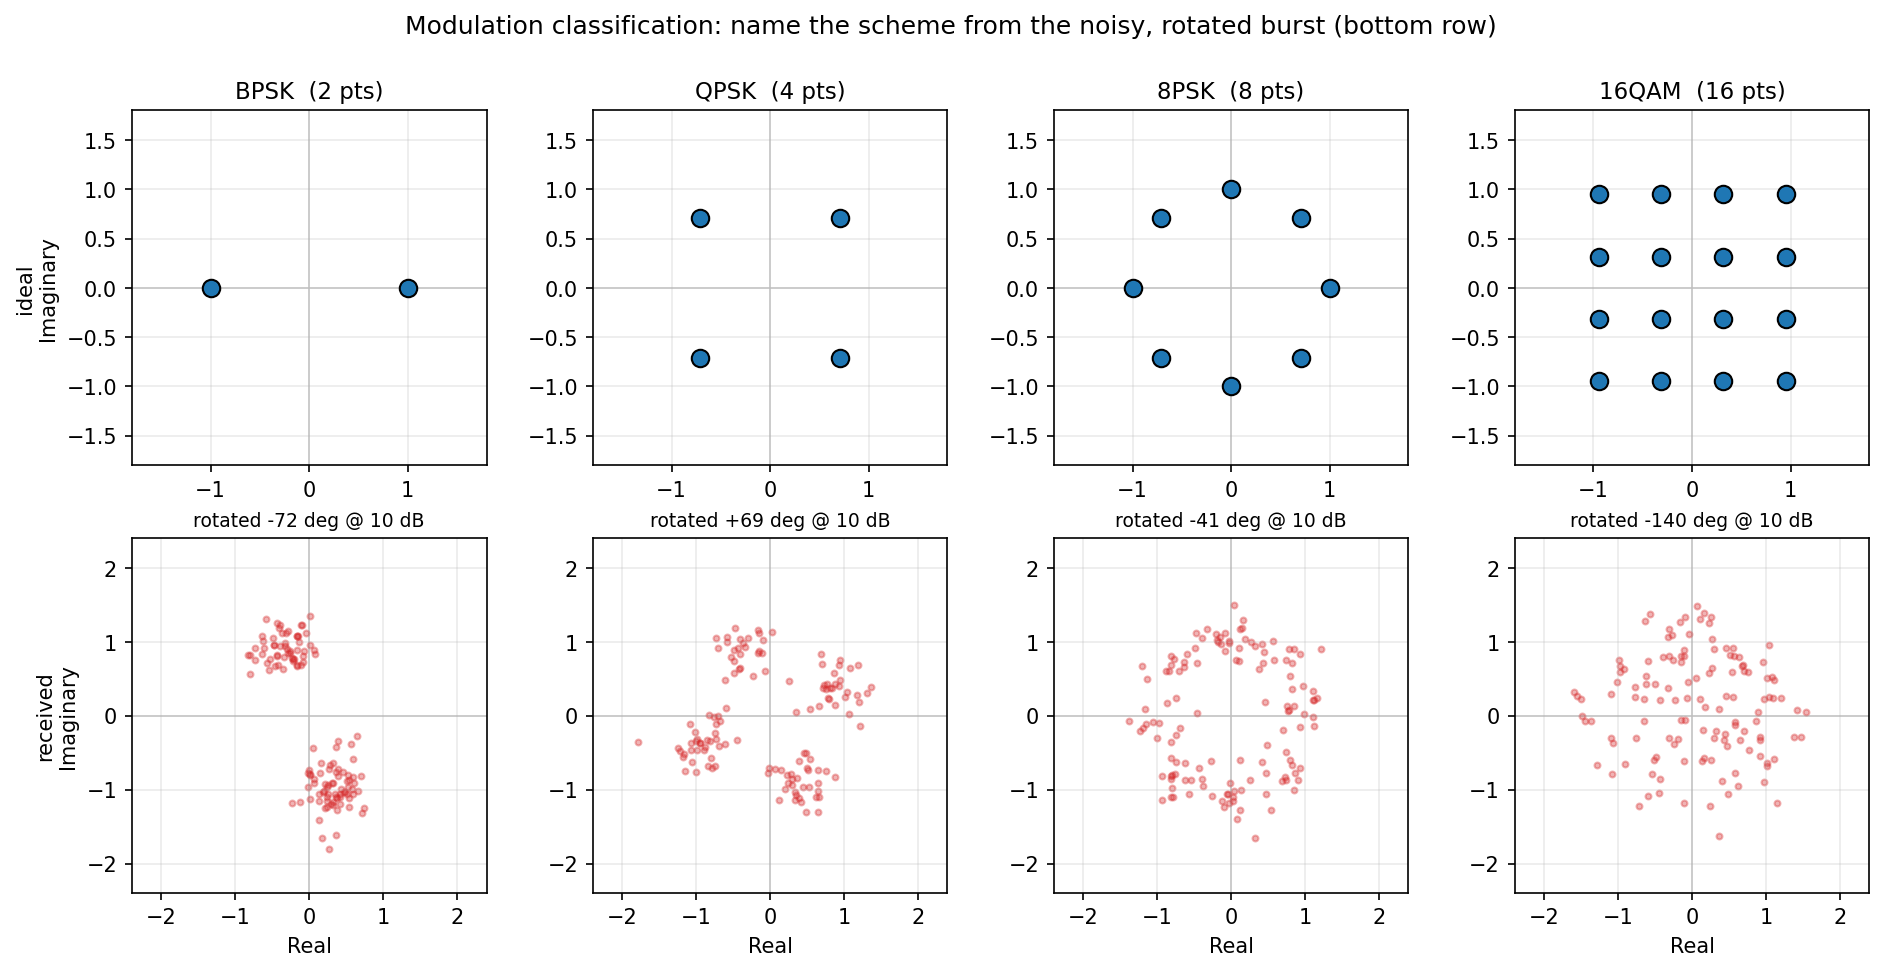

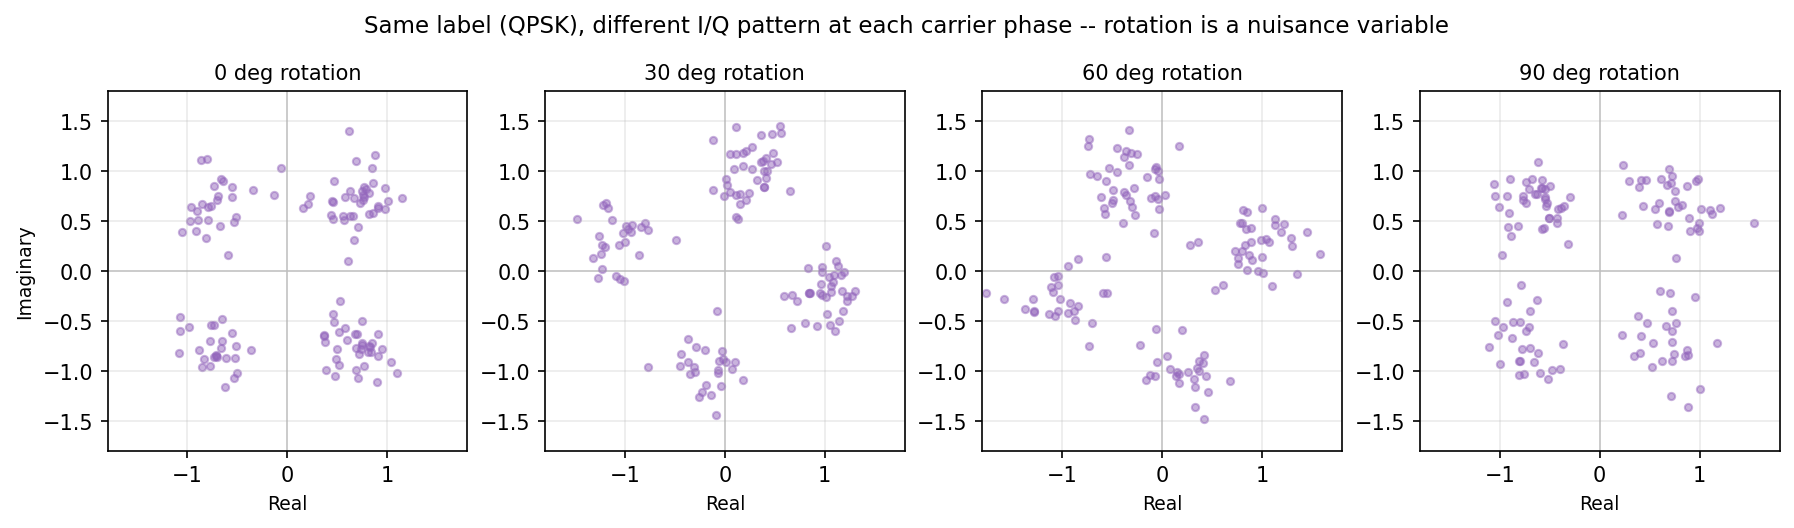

In [10]:
plot_constellations(cfg, str(VIZ_DIR))
plot_rotation_nuisance(cfg, str(VIZ_DIR), mod='qpsk')

show_png(VIZ_DIR / 'modclass_constellations.png')
show_png(VIZ_DIR / 'modclass_rotation_nuisance.png')

## 4) Data and model sanity checks

In [11]:
sample = generate_dataset(12, cfg, -cfg.train_phase_deg, cfg.train_phase_deg, seed_offset=0)
print('iq shape:', sample['iq'].shape)
print('label shape:', sample['label'].shape)
print('theta deg range:', np.rad2deg(sample['theta']).min(), np.rad2deg(sample['theta']).max())

for model_name in ['complex', 'complex_moment', 'real']:
    model = build_model(model_name, cfg).to(device)
    print(model_name, count_parameters(model))

iq shape: (12, 128)
label shape: (12,)
theta deg range: -13.586605 13.794056
complex {'count': 37295, 'real': 61655}
complex_moment {'count': 36127, 'real': 60487}
real {'count': 60964, 'real': 60964}


## 5) Train runs

In [12]:
specs = run_specs(cfg)
histories = {}
for run in SELECTED_RUNS:
    model_name, train_phase_deg = specs[run]
    histories[run] = train_one(
        run_name=run,
        model_name=model_name,
        train_phase_deg=train_phase_deg,
        cfg=cfg,
        device=device,
        out_root=str(OUT_ROOT),
    )


  Run: complex_moment  (model=complex_moment, train theta in +/-15 deg)
  params: 36,127 (60,487 real-equiv)
  epoch   1/25  loss=1.3403  val_acc[in-dist]=0.4993  val_acc[full-circle]=0.5010  (0.2s)
  epoch   2/25  loss=1.0013  val_acc[in-dist]=0.4968  val_acc[full-circle]=0.5032  (0.2s)
  epoch   3/25  loss=0.8422  val_acc[in-dist]=0.4988  val_acc[full-circle]=0.5025  (0.2s)
  epoch   4/25  loss=0.8300  val_acc[in-dist]=0.5265  val_acc[full-circle]=0.5298  (0.2s)
  epoch   5/25  loss=0.8201  val_acc[in-dist]=0.5510  val_acc[full-circle]=0.5497  (0.2s)
  epoch   6/25  loss=0.7597  val_acc[in-dist]=0.7390  val_acc[full-circle]=0.7405  (0.3s)
  epoch   7/25  loss=0.4442  val_acc[in-dist]=0.9712  val_acc[full-circle]=0.9665  (0.2s)
  epoch   8/25  loss=0.1781  val_acc[in-dist]=0.9818  val_acc[full-circle]=0.9790  (0.2s)
  epoch   9/25  loss=0.0978  val_acc[in-dist]=0.9815  val_acc[full-circle]=0.9815  (0.2s)
  epoch  10/25  loss=0.0738  val_acc[in-dist]=0.9778  val_acc[full-circle]=0.976

## 6) Evaluate rotation and SNR generalization

In [13]:
models = {r: load_run(r, cfg, str(OUT_ROOT), device) for r in SELECTED_RUNS}
models = {r: m for r, m in models.items() if m is not None}
print('loaded runs:', list(models.keys()))

angles = np.arange(-180, 181, 5.0)
snrs = [20, 15, 10, 5, 0, -5, -10]
n_eval = 300 if FAST_MODE else 2000
n_snr = 600 if FAST_MODE else 4000

sweep = {
    r: [accuracy_at_angle(m, cfg, a, cfg.snr_db, device, n=n_eval) for a in angles]
    for r, m in models.items()
}
per_mod = {
    r: [accuracy_at_angle(m, cfg, a, cfg.snr_db, device, n=n_eval, per_class=True) for a in angles]
    for r, m in models.items()
}
snr_acc = {
    r: [accuracy_full_circle(m, cfg, s, device, n=n_snr) for s in snrs]
    for r, m in models.items()
}
cms = {
    r: {
        0.0: confusion_at_angle(m, cfg, 0.0, cfg.snr_db, device, n=n_snr),
        90.0: confusion_at_angle(m, cfg, 90.0, cfg.snr_db, device, n=n_snr),
    }
    for r, m in models.items()
}

loaded runs: ['complex_moment', 'complex_narrow', 'real_narrow', 'real_full']


## 7) Save figures and JSON results

  saved visualizations/rotation_generalization.png
  saved visualizations/rotation_per_modulation.png
  saved visualizations/snr_sweep_modclass.png
  saved visualizations/confusion_in_vs_ood.png
saved results/rotation_sweep_notebook.json


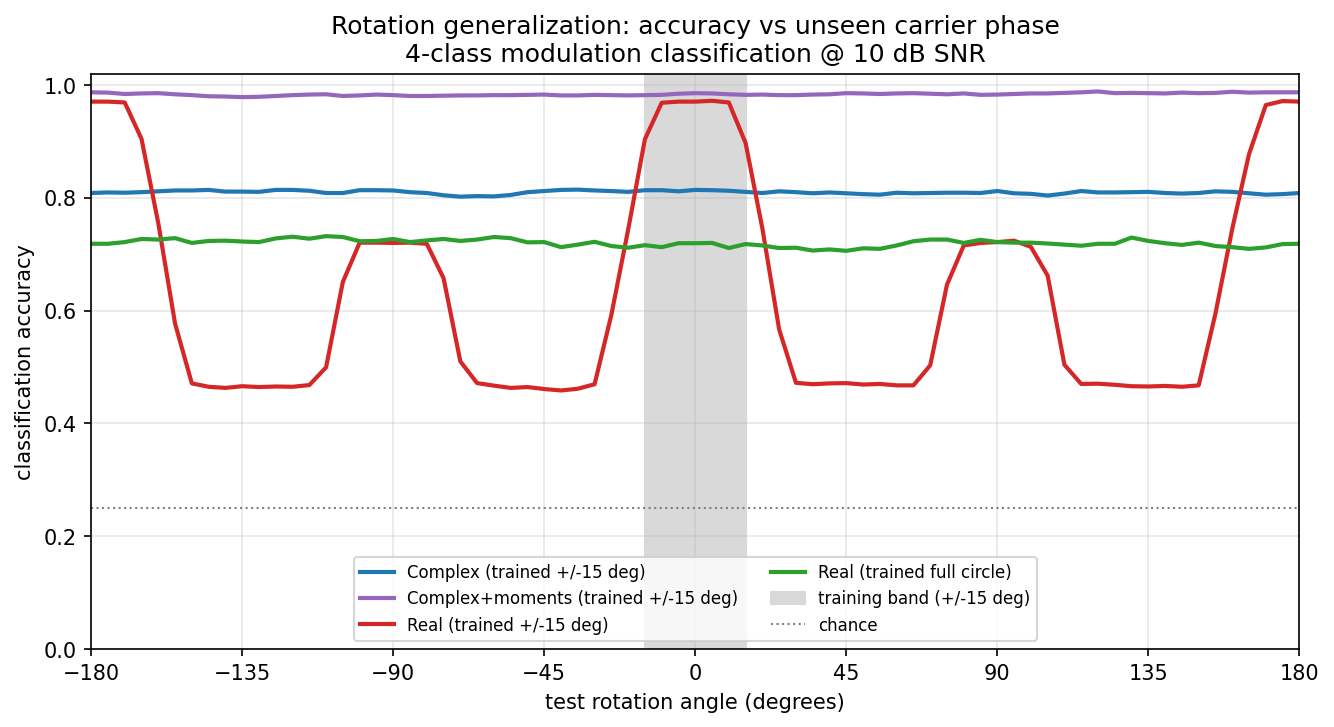

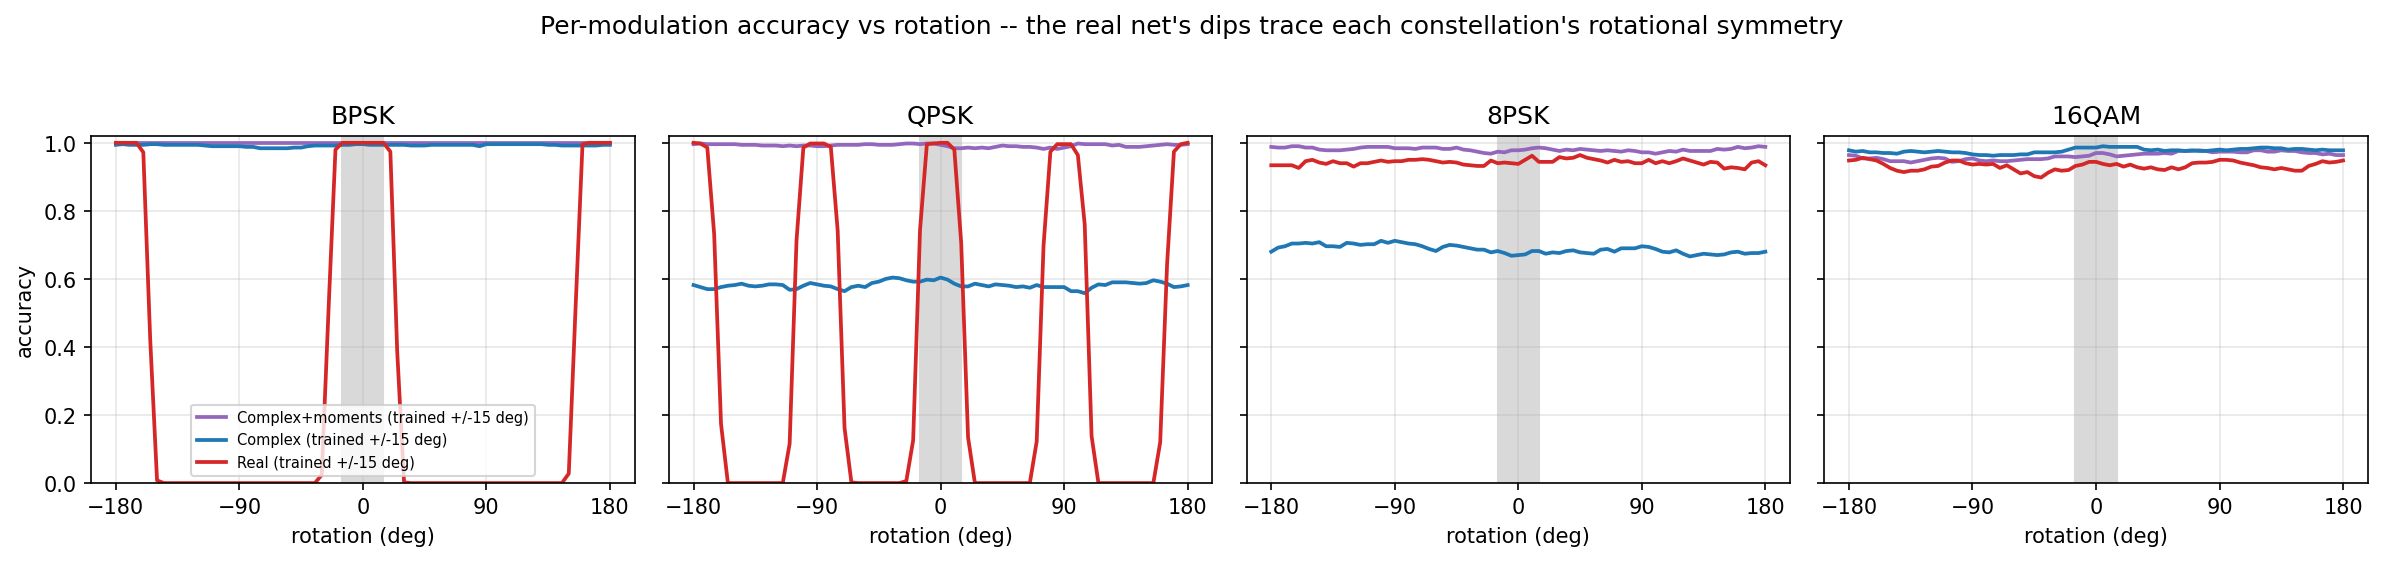

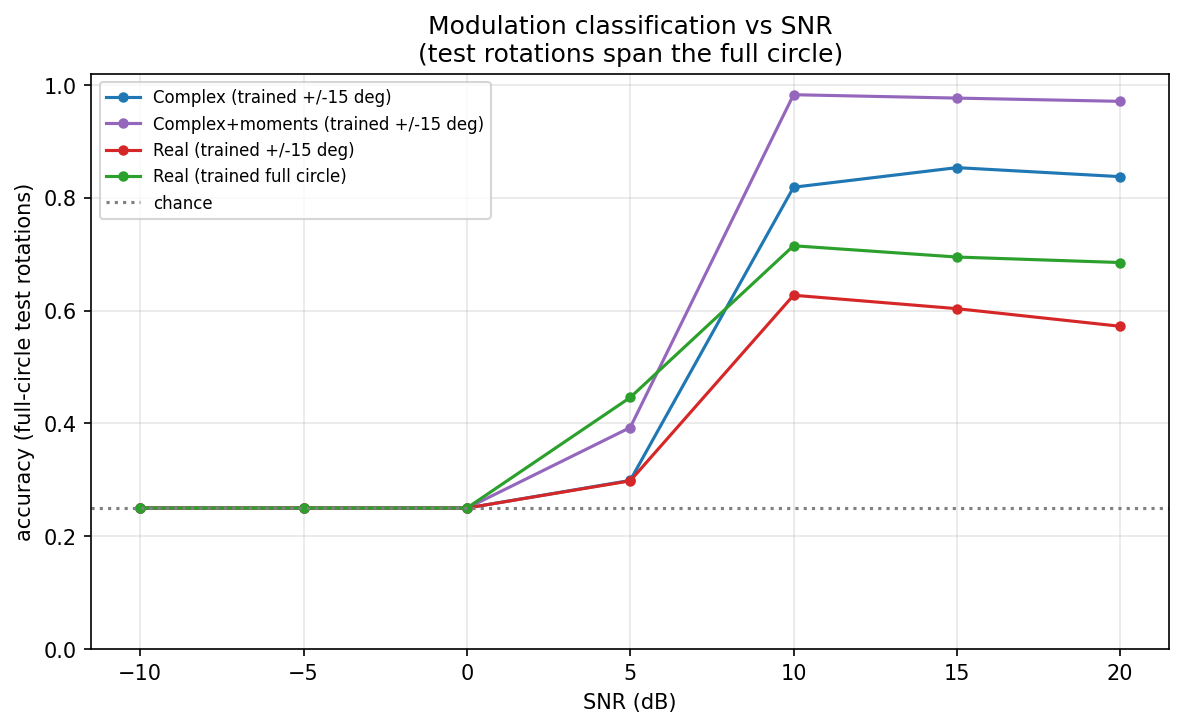

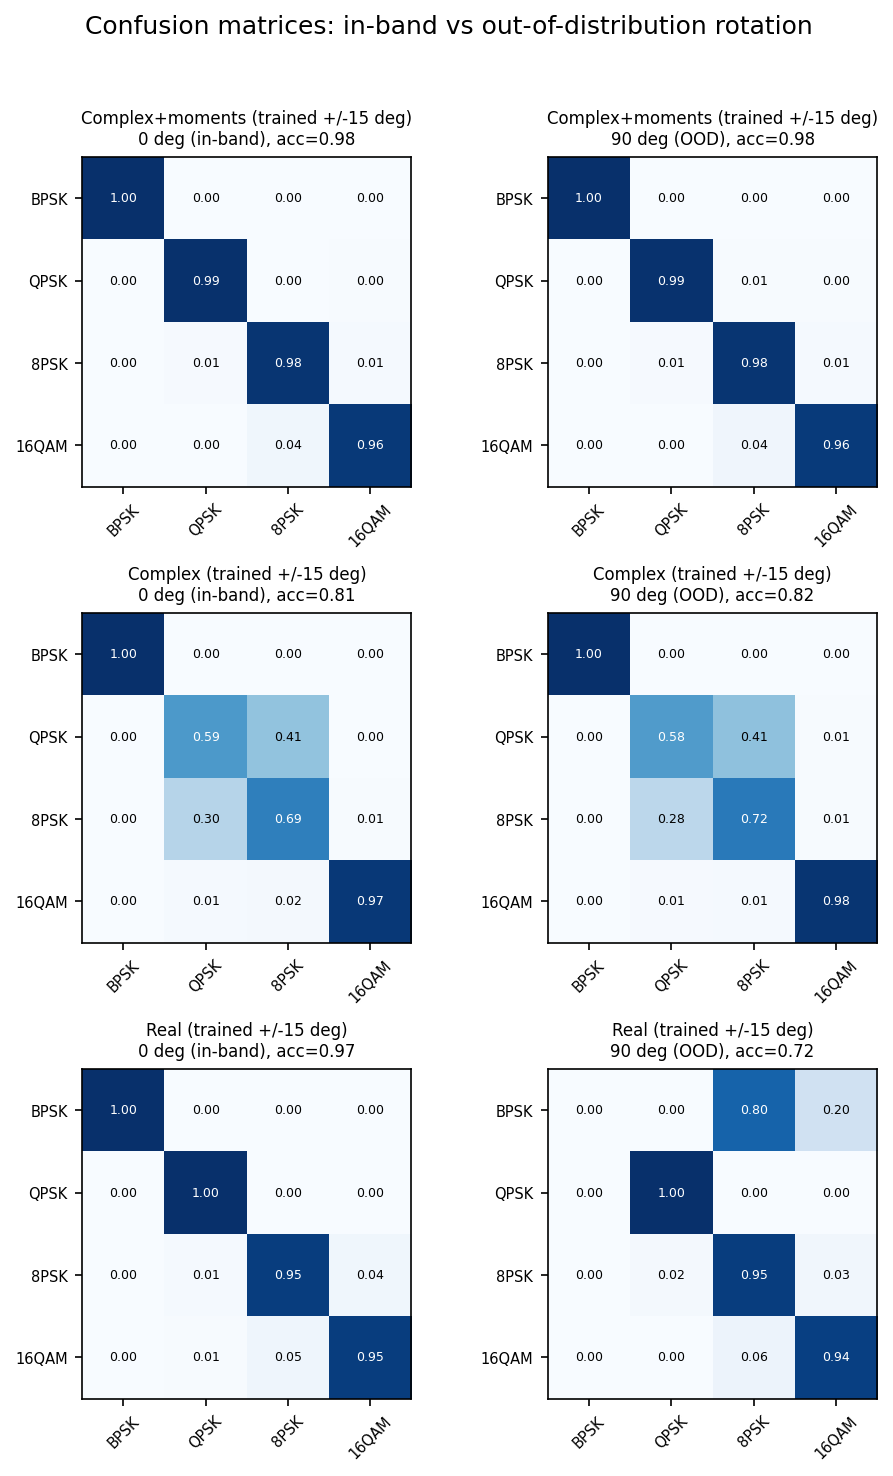

{'complex_moment': {'acc@0deg': 0.9855000376701355,
  'acc@90deg': 0.9830000400543213,
  'min_over_circle': 0.9785000681877136,
  'mean_over_circle': 0.9836096388019927},
 'complex_narrow': {'acc@0deg': 0.8140000104904175,
  'acc@90deg': 0.812000036239624,
  'min_over_circle': 0.8020000457763672,
  'mean_over_circle': 0.809774008515763},
 'real_narrow': {'acc@0deg': 0.9705000519752502,
  'acc@90deg': 0.721500039100647,
  'min_over_circle': 0.4585000276565552,
  'mean_over_circle': 0.6347808552114931},
 'real_full': {'acc@0deg': 0.7195000052452087,
  'acc@90deg': 0.721500039100647,
  'min_over_circle': 0.706000030040741,
  'mean_over_circle': 0.719890442613053}}

In [14]:
plot_rotation_generalization(angles, sweep, cfg, str(VIZ_DIR / 'rotation_generalization.png'))
plot_per_modulation(angles, per_mod, cfg, str(VIZ_DIR / 'rotation_per_modulation.png'))
plot_snr_sweep(snrs, snr_acc, cfg, str(VIZ_DIR / 'snr_sweep_modclass.png'))
plot_confusion(cms, cfg, str(VIZ_DIR / 'confusion_in_vs_ood.png'))

summary = {}
for r, vals in sweep.items():
    summary[r] = {
        'acc@0deg': vals[list(angles).index(0.0)],
        'acc@90deg': vals[list(angles).index(90.0)],
        'min_over_circle': float(np.min(vals)),
        'mean_over_circle': float(np.mean(vals)),
    }

result = {
    'angles_deg': angles.tolist(),
    'snrs_db': snrs,
    'rotation_sweep': sweep,
    'snr_sweep': snr_acc,
    'summary': summary,
}

out_json = RESULTS_DIR / 'rotation_sweep_notebook.json'
with open(out_json, 'w') as f:
    json.dump(result, f, indent=2)

print('saved', out_json)

show_png(VIZ_DIR / 'rotation_generalization.png')
show_png(VIZ_DIR / 'rotation_per_modulation.png')
show_png(VIZ_DIR / 'snr_sweep_modclass.png')
show_png(VIZ_DIR / 'confusion_in_vs_ood.png')

summary

## 8) Notes

- Keep `FAST_MODE=True` for quick checks.
- For final post-quality metrics, set `FAST_MODE=False` and rerun sections 5-7.